## 1. Setup


In [1]:
import sys
from pathlib import Path

import pandas as pd

# Add src/ to the path so we can import project modules
sys.path.insert(0, str(Path("..").resolve() / "src"))

from face_detector import get_detector

In [2]:
PROCESSED_DIR = Path("..").resolve() / "data" / "processed"

records = []
for label, folder in [(1, "smile"), (0, "non_smile")]:
    folder_path = PROCESSED_DIR / folder
    for img_path in sorted(folder_path.glob("*.jpg")):
        records.append({
            "filename": img_path.name,
            "filepath": str(img_path),
            "label": label,
        })

df = pd.DataFrame(records)

print(f"Total images: {len(df)}")
print(df["label"].value_counts().rename({1: "smile", 0: "non_smile"}))

Total images: 3999
label
smile        2171
non_smile    1828
Name: count, dtype: int64


## 2. Baseline Detection


In [3]:
import cv2
import numpy as np
from tqdm.notebook import tqdm

detector = get_detector()

n_faces_list = []
kps_list = []
det_score_list = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Detecting faces"):
    img = cv2.imread(row["filepath"])
    if img is None:
        n_faces_list.append(0)
        kps_list.append(None)
        det_score_list.append(None)
        continue

    faces = detector.detect(img)
    n_faces_list.append(len(faces))

    if len(faces) == 1:
        kps_list.append(faces[0].kps)
        det_score_list.append(faces[0].det_score)
    else:
        kps_list.append(None)
        det_score_list.append(None)

df_baseline = df.copy()
df_baseline["n_faces"] = n_faces_list
df_baseline["kps"] = kps_list
df_baseline["det_score"] = det_score_list

CACHE_DIR = Path("..").resolve() / "data" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
df_baseline.to_pickle(CACHE_DIR / "detections_baseline.pkl")

print("Saved df_baseline to data/cache/detections_baseline.pkl")
print("\n--- n_faces distribution ---")
dist = df_baseline["n_faces"].value_counts().sort_index()
dist.index = dist.index.map(lambda x: f"{x}+" if x >= 3 else str(x))
print(dist.groupby(level=0).sum() if dist.index.duplicated().any() else dist.to_string())

Detecting faces:   0%|          | 0/3999 [00:00<?, ?it/s]

Saved df_baseline to data/cache/detections_baseline.pkl

--- n_faces distribution ---
n_faces
0        6
1     3965
2       26
3+       2


Images with 0 faces detected: 6


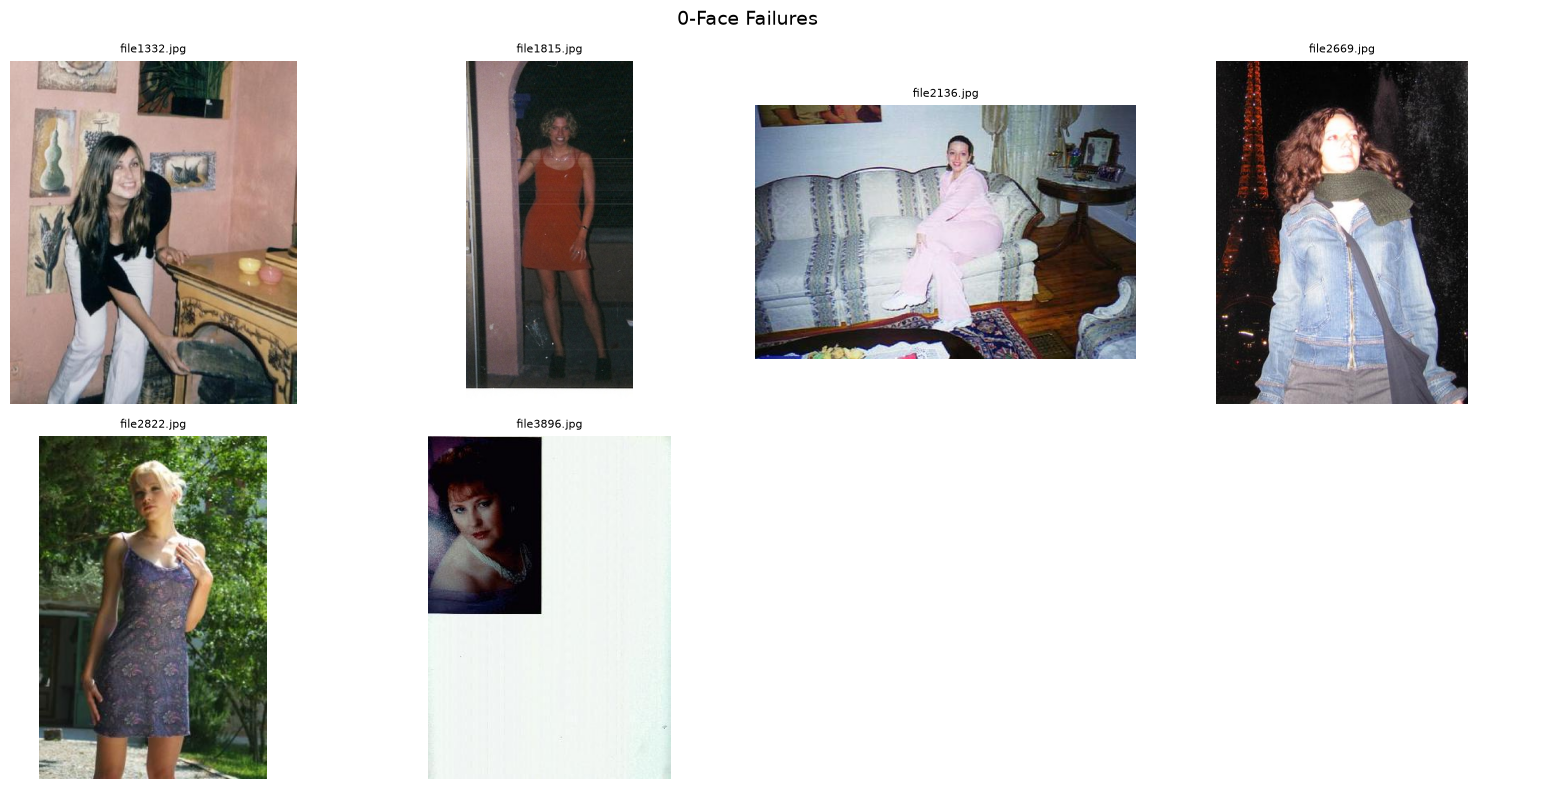

In [4]:
import math
import matplotlib.pyplot as plt

no_faces = df_baseline[df_baseline["n_faces"] == 0]
print(f"Images with 0 faces detected: {len(no_faces)}")

if len(no_faces) > 0:
    n_cols = 4
    n_rows = math.ceil(len(no_faces) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(no_faces.iterrows()):
        img = cv2.imread(row["filepath"])
        if img is not None:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(row["filename"], fontsize=8)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("0-Face Failures", fontsize=14)
    plt.tight_layout()
    plt.show()

12 lowest det_score among single-face detections:
    filename  label  det_score
file0488.jpg      1   0.564375
file1852.jpg      1   0.589104
file0625.jpg      1   0.592151
file1570.jpg      1   0.620511
file3838.jpg      0   0.623069
file0196.jpg      1   0.628257
file1946.jpg      1   0.641005
file3127.jpg      0   0.647996
file1944.jpg      1   0.653707
file2511.jpg      0   0.656506
file2607.jpg      0   0.661646
file2524.jpg      0   0.662795


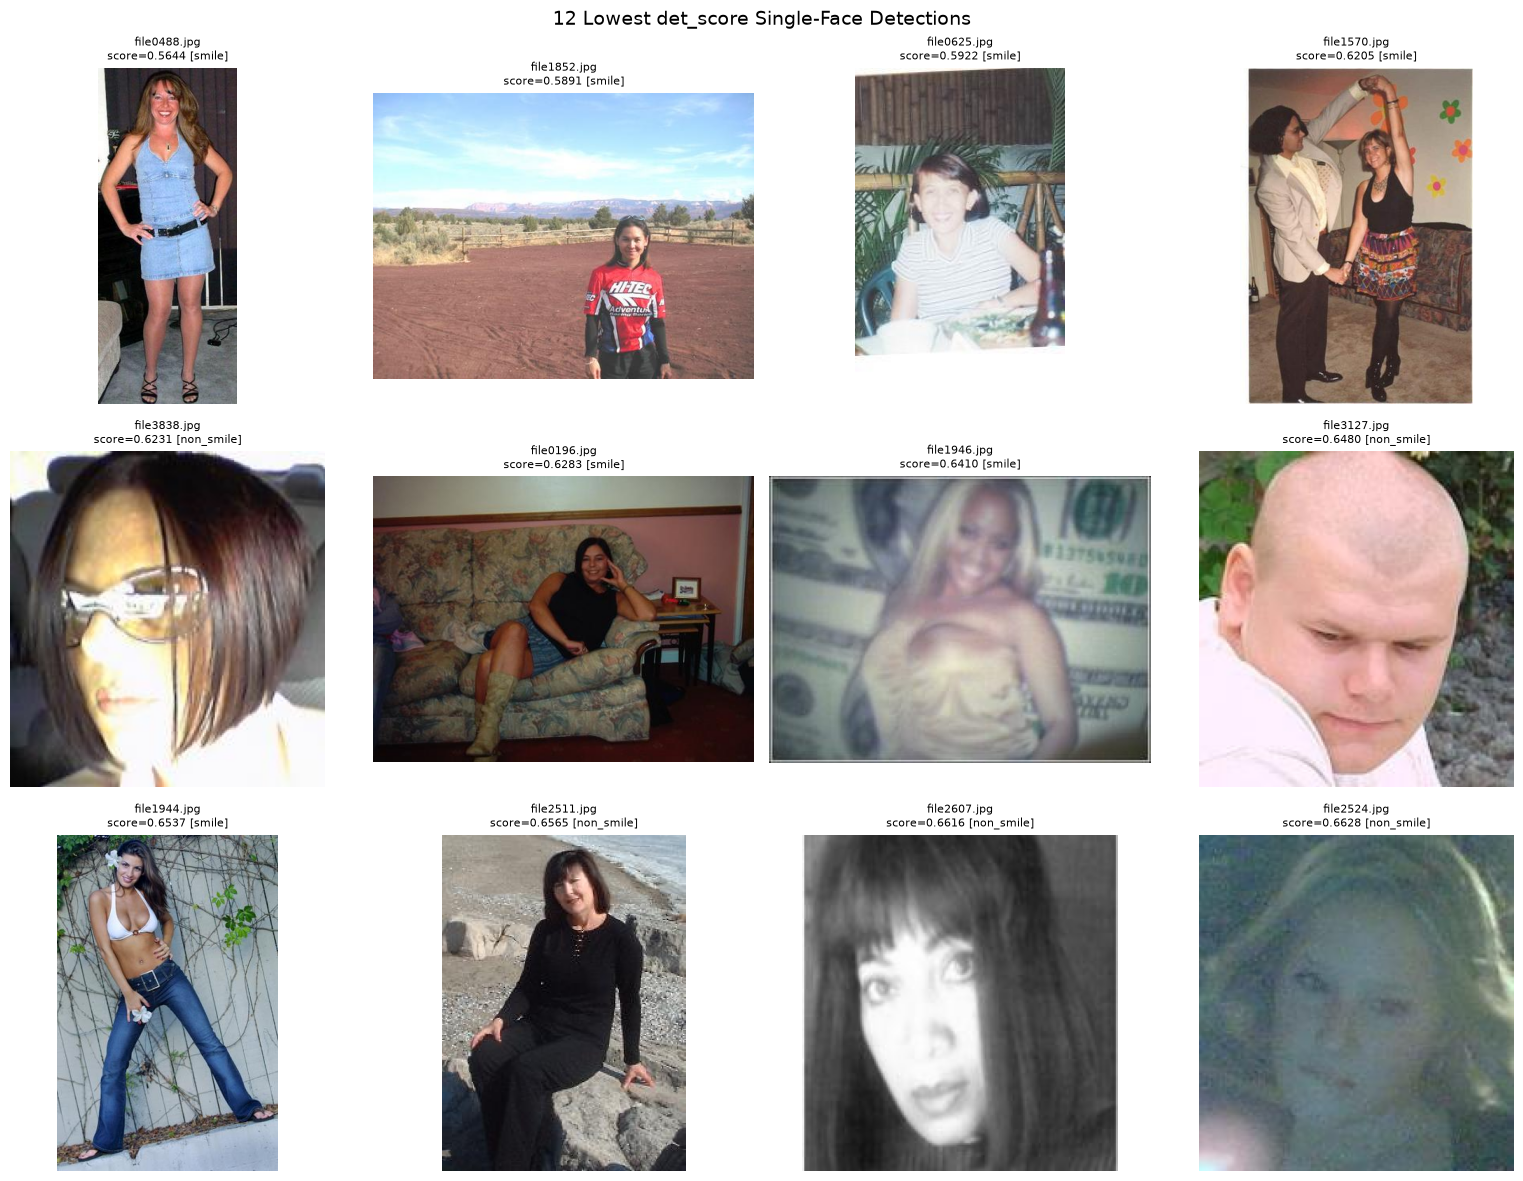

In [5]:
single_face = df_baseline[df_baseline["n_faces"] == 1].copy()
lowest_12 = single_face.sort_values("det_score").head(12)

print("12 lowest det_score among single-face detections:")
print(lowest_12[["filename", "label", "det_score"]].to_string(index=False))

n_cols = 4
n_rows = math.ceil(12 / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for i, (_, row) in enumerate(lowest_12.iterrows()):
    img = cv2.imread(row["filepath"])
    if img is not None:
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    label_str = "smile" if row["label"] == 1 else "non_smile"
    axes[i].set_title(
        f"{row['filename']}\nscore={row['det_score']:.4f} [{label_str}]",
        fontsize=8,
    )
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("12 Lowest det_score Single-Face Detections", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Fallback Experiment

CLAHE/gamma/grayscale were evaluated for detection recovery and found to have marginal effect (4-5 images); not pursued further.


In [6]:
from preprocessing import detect_with_fallback

n_faces_fb = []
kps_fb = []
det_score_fb = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Fallback detection"):
    img = cv2.imread(row["filepath"])
    if img is None:
        n_faces_fb.append(0)
        kps_fb.append(None)
        det_score_fb.append(None)
        continue

    faces = detect_with_fallback(detector, img)
    n_faces_fb.append(len(faces))

    if len(faces) == 1:
        kps_fb.append(faces[0].kps)
        det_score_fb.append(faces[0].det_score)
    else:
        kps_fb.append(None)
        det_score_fb.append(None)

df_det = df.copy()
df_det["n_faces"] = n_faces_fb
df_det["kps"] = kps_fb
df_det["det_score"] = det_score_fb

df_det.to_pickle(CACHE_DIR / "detections_raw.pkl")

print("Saved df_det to data/cache/detections_raw.pkl")
print("\n=== Before / After n_faces comparison ===")
before = df_baseline["n_faces"].value_counts().sort_index()
after = df_det["n_faces"].value_counts().sort_index()
comp = pd.DataFrame({"baseline": before, "fallback": after}).fillna(0).astype(int)
comp.index = comp.index.map(lambda x: f"{x}+" if x >= 3 else str(x))
comp = comp.groupby(level=0).sum()
comp["delta"] = comp["fallback"] - comp["baseline"]
print(comp.to_string())

Fallback detection:   0%|          | 0/3999 [00:00<?, ?it/s]

Saved df_det to data/cache/detections_raw.pkl

=== Before / After n_faces comparison ===
         baseline  fallback  delta
n_faces                           
0               6         0     -6
1            3965      3971      6
2              26        26      0
3+              2         2      0


In [7]:
from utils import compute_image_stats

brightness_vals = []
blur_vals = []
for _, row in tqdm(df_det.iterrows(), total=len(df_det), desc="Image quality"):
    img = cv2.imread(row["filepath"])
    s = compute_image_stats(img)
    brightness_vals.append(s["brightness"])
    blur_vals.append(s["blur_val"])

df_det["brightness"] = brightness_vals
df_det["blur"] = blur_vals

print(df_det[["brightness", "blur"]].describe().to_string())


Image quality:   0%|          | 0/3999 [00:00<?, ?it/s]

        brightness          blur
count  3999.000000   3999.000000
mean    111.475535    448.238077
std      31.773703    572.210827
min      14.482256      5.211907
25%      88.761799    153.410463
50%     110.435551    287.059588
75%     132.357089    537.953021
max     238.697522  11231.301680


## 4. Clean Dataset


In [8]:
# Ensure the full df_det (all n_faces values) is on disk for later benchmarking
df_det.to_pickle(CACHE_DIR / "detections_raw.pkl")

# Clean dataset: single-face only
dataset_clean = (
    df_det[df_det["n_faces"] == 1]
    .drop(columns=["n_faces"])
    .reset_index(drop=True)
)
dataset_clean.to_pickle(CACHE_DIR / "dataset_clean.pkl")

print(f"dataset_clean images: {len(dataset_clean)}")
print(dataset_clean["label"].value_counts().rename({1: "smile", 0: "non_smile"}))
print(f"\n(df_det with all {len(df_det)} rows kept at data/cache/detections_raw.pkl)")

dataset_clean images: 3971
label
smile        2151
non_smile    1820
Name: count, dtype: int64

(df_det with all 3999 rows kept at data/cache/detections_raw.pkl)


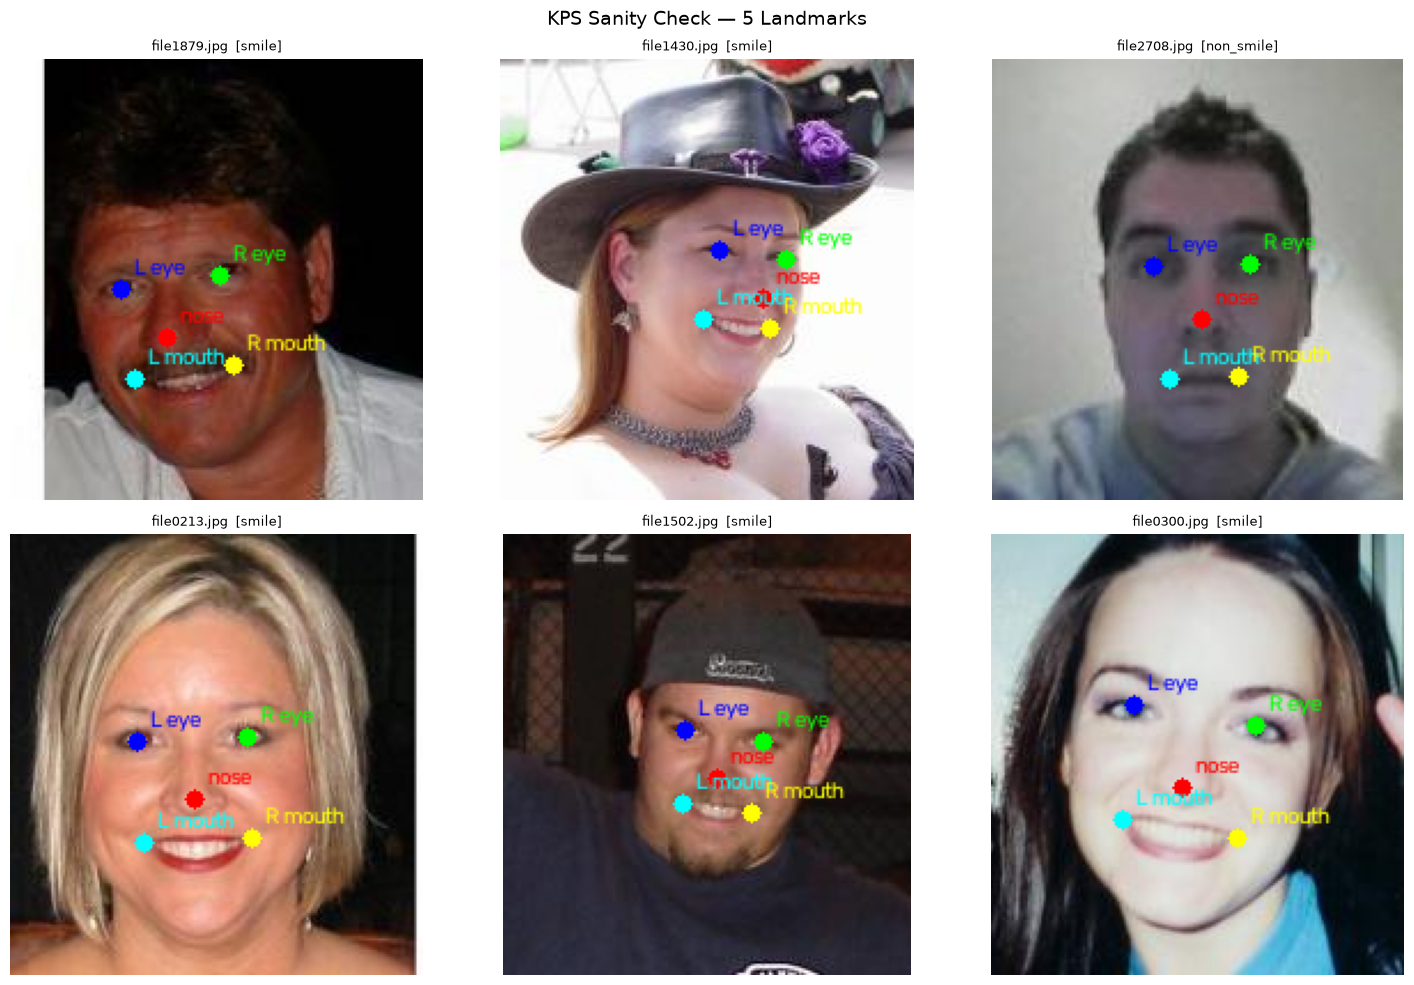

In [9]:
KPS_LABELS = ["L eye", "R eye", "nose", "L mouth", "R mouth"]
KPS_COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

sample = dataset_clean.sample(n=min(6, len(dataset_clean)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sample.iterrows()):
    img = cv2.imread(row["filepath"])
    if img is None:
        axes[i].axis("off")
        continue

    kps = row["kps"]  # (5, 2) ndarray
    for j, (px, py) in enumerate(kps.astype(int)):
        cv2.circle(img, (px, py), 4, KPS_COLORS[j], -1)
        cv2.putText(img, KPS_LABELS[j], (px + 6, py - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, KPS_COLORS[j], 1, cv2.LINE_AA)

    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    label_str = "smile" if row["label"] == 1 else "non_smile"
    axes[i].set_title(f"{row['filename']}  [{label_str}]", fontsize=9)
    axes[i].axis("off")

plt.suptitle("KPS Sanity Check — 5 Landmarks", fontsize=14)
plt.tight_layout()
plt.show()